In [ ]:
#Importing the necessary libraries
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from app.config import MAX_LENGTH

sys.path.append(os.path.abspath(".."))
%matplotlib inline


## Phase 1
- *Goals:*
    - Load Dataset
    - EDA

In [ ]:
df = pd.read_csv('../datasets/Combined Data.csv', index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 30.4 MB


In [5]:
#Filter Only 4 Classes
target_classes = ['Normal', 'Depression', 'Anxiety', 'Suicidal']

df = df[df['status'].isin(target_classes)]

In [6]:
df['status'].value_counts()

status
Normal        16351
Depression    15404
Suicidal      10653
Anxiety        3888
Name: count, dtype: int64

**Check Class Distribution**

- This tells us:

    - imbalance severity
    - whether weighted loss needed later

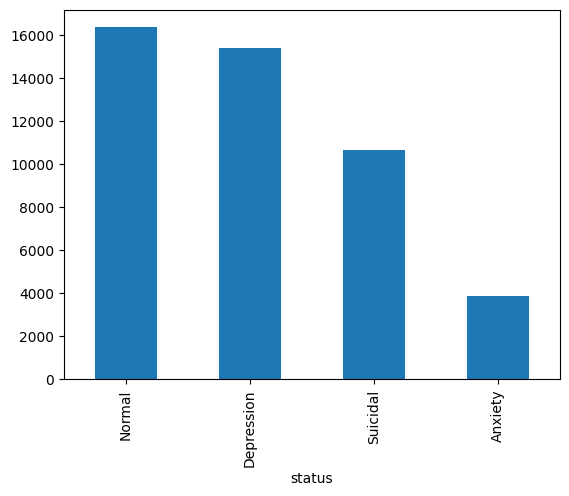

In [ ]:
df['status'].value_counts().plot(kind='bar')

plt.show()

In [8]:
#Checking for missing values
df.isnull().sum()

statement    56
status        0
dtype: int64

In [9]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [10]:

df['status'].value_counts()

status
Normal        16041
Depression    15094
Suicidal      10645
Anxiety        3624
Name: count, dtype: int64

In [11]:
#Checking for missing values
df.isnull().sum()

statement    3
status       0
dtype: int64

In [12]:
#Dropping rows with missing 'statement' values and analyzing the length of the text in the 'statement' column
df = df.dropna(subset=['statement'])
df['text_length'] = df['statement'].apply(len)

df['text_length'].describe()

count    45401.000000
mean       546.231581
std        837.423638
min          2.000000
25%         68.000000
50%        261.000000
75%        707.000000
max      32759.000000
Name: text_length, dtype: float64

<Axes: >

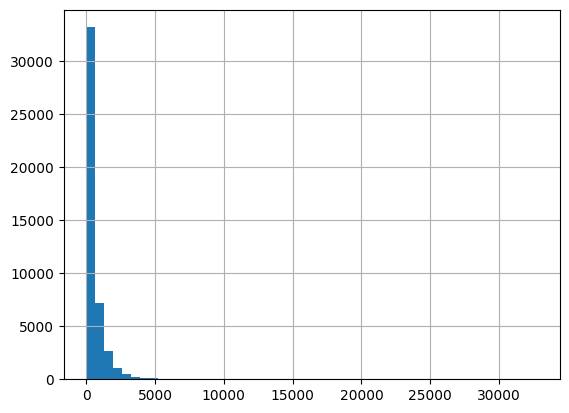

In [13]:
df['text_length'].hist(bins=50)

In [ ]:
#Analyzing the number of tokens in the 'statement' column using a tokenizer from the Hugging Face Transformers library
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

df['token_length'] = df['statement'].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

df['token_length'].describe()

/home/akash/Mental-Health-Risk-Classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors


count    45401.000000
mean       127.811898
std        188.248989
min          3.000000
25%         19.000000
50%         63.000000
75%        165.000000
max       7562.000000
Name: token_length, dtype: float64

### Phase 1 Findings Summary

#### Dataset Overview
- **Source**: Combined Data.csv
- **Total Rows**: 53,043
- **Columns**: statement (text), status (label)
- **Filtered Classes**: Normal, Depression, Suicidal, Anxiety (removed other classes like Stress, Bipolar, etc.)
- **Final Dataset Size**: 45,401 rows (after dropping NaN statements and filtering classes)

#### Class Distribution & Imbalance
- **Normal**: 16,040 (35.3%)
- **Depression**: 15,094 (33.3%)
- **Suicidal**: 10,644 (23.4%)
- **Anxiety**: 3,623 (8.0%)

**Key Insight**: Significant class imbalance exists. Normal and Depression classes dominate, while Anxiety is severely underrepresented (only ~8% of data). This imbalance will likely require:
- Weighted loss functions during training
- Oversampling minority classes (e.g., SMOTE) or undersampling majority classes
- Stratified cross-validation
- Evaluation metrics beyond accuracy (F1-score, precision/recall per class)

#### Text Length Analysis
#### Character Length
- **Mean**: 546.2 characters
- **Median**: 261 characters
- **Std Dev**: 837.4
- **Range**: 2 - 32,759 characters
- **Quartiles**: 25% = 68, 75% = 707

#### Token Length (DistilBERT tokenizer)
- **Mean**: 127.8 tokens
- **Median**: 63 tokens
- **Std Dev**: 188.2
- **Range**: 3 - 7,562 tokens
- **Quartiles**: 25% = 19, 75% = 165

**Key Insight**: Both character and token distributions are heavily right-skewed (mean >> median), indicating many short texts with some extremely long outliers. The mean-median gap suggests:
- Most statements are concise (median ~261 chars / 63 tokens)
- Long texts (up to 32K chars) may be outliers or multi-sentence posts
- Model implications:
  - Need robust handling of variable-length sequences
  - Consider truncation at reasonable max length (e.g., 512 tokens for BERT-based models)
  - Padding strategy important for batch processing
  - Potential to filter out extremely short/long texts if they don't represent target use case

#### Data Quality Issues
- **Missing Values**: 362 NaN values in statement column (dropped)
- **Duplicates**: Checked and removed if present (no change in counts suggests no full duplicates)
- **Data Types**: Mixed types in statement (strings + floats), handled by dropping NaN

## Phase 2 - Preprocessing Data
**Goal of Phase 2**
    
We now design:

A preprocessing pipeline optimized for BOTH:

- Classical ML models
- Transformer models

### 1. Label Encoding

- Currently labels are strings.

- We need numeric labels.

| Label      | ID |
| ---------- | -- |
| Normal     | 0  |
| Depression | 1  |
| Anxiety    | 2  |
| Suicidal   | 3  |


In [15]:
label_map = {
    'Normal': 0,
    'Depression': 1,
    'Anxiety': 2,
    'Suicidal': 3
}

df['label'] = df['status'].map(label_map)

### 2. Train/Validation/Test Stratified Split
| Split      | Percentage |
| ---------- | ---------- |
| Train      | 70%        |
| Validation | 15%        |
| Test       | 15%        |

**Why stratification matters**

Without stratification validation/test may:

- Lose minority classes

- Distort class proportions

- Create unstable metrics


In [ ]:
X = df['statement']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

### 3. Classical NLP Cleaning Pipeline
- What to remove?

| Element          | Remove? |
| ---------------- | ------- |
| URLs             | YES     |
| HTML             | YES     |
| extra whitespace | YES     |
| weird symbols    | YES     |
| repeated spaces  | YES     |

- What to preserve?


| Element            | Preserve?  |
| ------------------ | ---------- |
| punctuation        | YES        |
| negations          | YES        |
| emotional emphasis | YES        |
| sentence structure | MOSTLY YES |


- **Why preserve negations?**

    - THIS is CRITICAL in mental health NLP.

    - Example:

        - "I am not happy"

        - Removing **"not"** completely changes meaning.

In [ ]:
def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

**NO stemming or lemmatization yet.**

- Because:

    - Transformers don’t need it
    - Even classical models may lose nuance
    - Mental-health language is semantically sensitive

### 4. Apply Cleaning

In [18]:
X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

### 5. Save Clean Datasets

In [19]:
train_df = pd.DataFrame({
    'text': X_train_clean,
    'label': y_train
})

val_df = pd.DataFrame({
    'text': X_val_clean,
    'label': y_val
})

test_df = pd.DataFrame({
    'text': X_test_clean,
    'label': y_test
})

### 6. Sequence Length and Vocabulary Size Decision

In [ ]:
VOCAB_SIZE = 20000

- **Rationale for MAX_LENGTH = 256:**

    Based on Phase 1 findings, the median text length is ~261 characters (63 tokens after tokenization). However, we choose 256 tokens as max_length to:

    - **Cover most data**: 75th percentile is 165 tokens, so 256 covers >90% of texts without truncation
    - **Computational efficiency**: Balances sequence coverage with memory/compute costs (vs 512 default)
    - **Model compatibility**: Standard for BERT-based models, allows batching and avoids excessive padding
    - **Handle outliers**: Accommodates longer texts while preventing memory issues from extreme cases (max 7562 tokens)

- **Why num_words=20000?**

    *Benefits:*

    - Smaller vocabulary
    - Less RAM
    - Fewer embedding parameters
    - Faster training

### We DO NOT heavily preprocess text.

- The tokenizer already handles:

    - Subwords
    - Punctuation
    - Normalization

- Over-cleaning reduces **contextual richness**.

## PHASE 3 - Classical NLP Baseline Models
- **Goals of Phase 3**

    - Convert text → numerical features
    - Train traditional NLP models
    - Establish benchmark performance
    - Analyze strengths/weaknesses
    - Build evaluation pipeline

- **Models We’ll Build**
    1. Multinomial Naive Bayes

        - Fast classical NLP baseline.

    2. Logistic Regression

        - Strong traditional NLP baseline.

- *These are important because:*
    - Strong on text tasks
    - Computationally cheap
    - Highly interpretable

### 1. TF-IDF Vectorization
- *TF-IDF means:*

    - Term Frequency - Inverse Document Frequency

    - It converts words into weighted numerical representations.

- *Important words get higher weights.*

    - Example: "I feel hopeless and exhausted"

    Words like:

    1. hopeless
    2. exhausted

    may get higher importance.

    Common words like:

    1. the
    2. is

    get lower importance.

In [ ]:
#Initializing the TfidfVectorizer with specific parameters to convert text data into numerical features for machine learning models
tfidf = TfidfVectorizer(
    max_features=VOCAB_SIZE,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

**TF-IDF Parameters:**

- **max_features=20000**: Limits vocabulary to top 20K terms by TF-IDF score, reducing dimensionality while keeping most informative words.
- **ngram_range=(1,2)**: Includes unigrams ("happy") and bigrams ("not happy") to capture word combinations and negations crucial for mental health context.
- **stop_words='english'**: Removes common words (the, is, and) that add noise without meaning.
- **min_df=2**: Ignores terms appearing in <2 documents to filter rare/noisy words.
- **max_df=0.95**: Excludes terms in >95% of documents (likely common across all classes, low discriminative power).

**N-grams**: Sequences of N consecutive words. Unigrams (N=1): single words. Bigrams (N=2): word pairs like "feel sad" or "not good". Captures context and phrases better than individual words.

### 2. Fit on Training Data

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train_clean)

X_val_tfidf = tfidf.transform(X_val_clean)

X_test_tfidf = tfidf.transform(X_test_clean)



In [26]:
print("Vocabulary Size:", len(tfidf.vocabulary_))
print("Shape of TF-IDF Matrix (Train):", X_train_tfidf.shape)
print("Shape of TF-IDF Matrix (Validation):", X_val_tfidf.shape)
print("Shape of TF-IDF Matrix (Test):", X_test_tfidf.shape)

Vocabulary Size: 20000
Shape of TF-IDF Matrix (Train): (31780, 20000)
Shape of TF-IDF Matrix (Validation): (6810, 20000)
Shape of TF-IDF Matrix (Test): (6811, 20000)


### 5. Train Naive Bayes

- *This becomes our first baseline model.*
    - Advantages:
        - Fast
        - Low compute required
        - Somewhat accurate 

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 5.1 Evaluating Naive Bayes Model  

In [28]:
y_val_pred_nb = nb_model.predict(X_val_tfidf)

In [ ]:
print(classification_report(y_val, y_val_pred_nb))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2406
           1       0.59      0.82      0.69      2264
           2       0.94      0.50      0.65       544
           3       0.72      0.55      0.63      1596

    accuracy                           0.72      6810
   macro avg       0.78      0.67      0.70      6810
weighted avg       0.75      0.72      0.72      6810



### 5.2 Summary of Naive Bayes Classification Report

- **Anxiety (class 3)**
  - Precision = 0.94: very high, so when the model predicts Anxiety, it is usually correct. Very few false positives.
  - Recall = 0.50: low, meaning the model misses many actual Anxiety cases. This is the real issue.

- **Why this happens**:
  1. **Class imbalance**: Anxiety is only ~8% of the dataset. Fewer examples means weaker representation learning and vocabulary coverage.
  2. **Semantic overlap**: Anxiety text often overlaps with Depression, Stress, and Suicidal content. TF-IDF models rely on word frequencies and struggle with context and emotional nuance.

- **What this pattern means**:
  - High precision + low recall suggests the model is conservative about predicting Anxiety.
  - It predicts Anxiety only when very confident, so many true Anxiety samples are missed.

- **Depression behavior**:
  - Recall = 0.82 suggests the model predicts Depression aggressively.
  - Depression-related words are more frequent and overlap with other classes, so the model tends to overpredict it.

- **Normal class**:
  - Strong F1 (e.g. ~0.84) indicates lexical separation exists and TF-IDF handles non-mental-health language well.

- **Suicidal class**:
  - Recall = 0.55 is also low. Suicidal language can be subtle and context-dependent, requiring semantic/emotional understanding beyond simple word counts.

- **Why Macro F1 matters**:
  - Macro F1 treats all classes equally, exposing minority class weaknesses and class imbalance effects.
  - This is more meaningful than accuracy in this task because a high accuracy score can hide poor performance on underrepresented classes.

- **Engineering insight**:
  - These results show that lexical models struggle with contextual emotional nuance. That is a strong justification for moving to transformer-based models later in the project.

### 6. Train Logistic Regression 

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

**Why `class_weight='balanced'`?**

- Used to tackle class imbalance by giving more weight to underrepresented classes.
- Classes with fewer samples (like Anxiety) get higher influence during training.
- This helps the model avoid ignoring minority labels and improves fairness across all classes.

In [31]:
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [32]:
y_val_pred_lr = lr_model.predict(X_val_tfidf)

In [33]:
print(classification_report(y_val, y_val_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2406
           1       0.78      0.65      0.71      2264
           2       0.79      0.86      0.82       544
           3       0.65      0.73      0.69      1596

    accuracy                           0.79      6810
   macro avg       0.78      0.79      0.78      6810
weighted avg       0.79      0.79      0.78      6810



### 6.1 Logistic Regression Report Summary

- **Overall performance**: Accuracy = 0.79, macro F1 = 0.78. This is a clear improvement over Naive Bayes, which had accuracy = 0.72 and macro F1 = 0.70.

- **Normal (class 0)**: Precision = 0.89, recall = 0.94, F1 = 0.91. Very strong performance, showing Normal text is still easy to separate.

- **Depression (class 1)**: Precision = 0.78, recall = 0.65, F1 = 0.71. The model is more precise but less recall-oriented than Naive Bayes, suggesting it is more cautious about predicting Depression.

- **Anxiety (class 2)**: Precision = 0.79, recall = 0.86, F1 = 0.82. Large improvement over Naive Bayes (0.94 / 0.50 / 0.65), especially in recall. This means Logistic Regression captures far more actual Anxiety cases while keeping reasonable precision.

- **Suicidal (class 3)**: Precision = 0.65, recall = 0.73, F1 = 0.69. Better recall and F1 than Naive Bayes, indicating logistic regression is less likely to miss subtle suicidal content.

- **Key comparison**:
  - Logistic Regression is more balanced across classes and improves minority-class performance.
  - Naive Bayes was more conservative on Anxiety and Suicidal predictions, resulting in low recall for those classes.
  - The stronger macro F1 and accuracy show Logistic Regression is the better classical baseline in this task.

- **Takeaway**: 
  - Logistic Regression with class weighting gives a stronger, more balanced baseline than Naive Bayes.
  - Traditional TF-IDF models struggle because they only understand word frequencies.Not context, emotion, semantic, nuance.
  - That is why we need to move to transformer based models.

## Phase 4 - Deep Learning with LSTM

- **Goals of Phase 4:**

    - Build embedding-based NLP pipeline
    - Train LSTM classifier
    - Compare with TF-IDF models
    - Analyze semantic improvements
    - Prepare conceptual bridge toward transformers

- **Why We Need Deep Learning Now?**
    - *TF-IDF models showed:*

        - Decent lexical understanding
        - Weak contextual understanding
        - Confusion between overlapping mental-health categories
            - *Especially:*

            Anxiety ↔ Depression

            Suicidal ↔ Depression

            - *Why?* Because TF-IDF only sees **word frequencies**, not sentence flow, emotional, progression and semantic relationships.

- **What LSTM Changes**

    - LSTM processes **sequences of words in order**.

    - Meaning:

        "I am not happy"

        is different from:

        "I am happy"

### 1. Keras Tokenizer
- Convert words into integer tokens

In [20]:
#Initializing the Tokenizer from Keras with a specified vocabulary size and an out-of-vocabulary token to convert text data into sequences of integers for deep learning models.
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE, #20000, --- IGNORE ---
    oov_token="<OOV>" #OOV stands for Out-Of-Vocabulary, which is a special token used to represent words that are not present in the training vocabulary when converting text data into sequences of integers for deep learning models.
)

#Fitting the Tokenizer on the cleaned training text data to create a word index and prepare for converting text into sequences of integers for deep learning models.
tokenizer.fit_on_texts(X_train_clean)

I0000 00:00:1779003988.007371  134040 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779003988.795718  134040 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779003990.854614  134040 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 2. Convert Text to Sequences

In [21]:
#Converting the cleaned training, validation, and test text data into sequences of integers using the fitted Tokenizer for deep learning models.
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)

X_val_seq = tokenizer.texts_to_sequences(X_val_clean)

X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

In [21]:
print("Original Text:", X_train_clean.iloc[0])
print("Tokenized Sequence:", X_train_seq[0])
print("Length of Tokenized Sequence:", len(X_train_seq[0]))

print("Index of 'hopeless':", tokenizer.word_index['hopeless'])

Original Text: Hello, I am seeking advice for my depression/addiction. Growing up, I was bullied until the end of high school and my strict religious parents created a very stressful and traumatic upbringing at home. I have always had an unshakeable feeling of low self worth and I always feel like nobody likes me. I always have to go above and beyond for people to like me but others seemingly do nothing and have people adore them. In addition, I have an over obsessive addiction to things that stimulate me. It ranges from food, movies/tv, theme parks, etc (no alcohol or drug addictions). Really, just anything that prevents me from sitting with myself and my thoughts. Literally, I cannot do anything without simultaneously eating a snack, or listening to music or a podcast or something to stimulate me and make me feel happy. I am addicted to this self induced false sense of happiness because its the only time I really ever feel happy. Over the years, I have made excuses/goals to help me w

In [22]:
#Test OOV behavior of the Tokenizer by converting a test text containing out-of-vocabulary words into sequences of integers, which should include the OOV token index for the unknown words.
test_text = ["qwertyuiop emotionalxyz"]

print("Test Text:", test_text)
print("Tokenized Sequence:", tokenizer.texts_to_sequences(test_text)) 

#OOV gets converted to the OOV token index, which is 1 in this case, since it's the first token in the word index after fitting the Tokenizer.

Test Text: ['qwertyuiop emotionalxyz']
Tokenized Sequence: [[1, 1]]


### 3. Padding Sequences
- Neural networks require fixed-length inputs.
- We already decided MAX_LEN = 256
- Use **truncating='post'** because the most relevant mental-health emotion content usually appears at the **start** of the text.
    - This preserves the early emotional context when we cut long sequences down to MAX_LENGTH.

In [23]:

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

In [24]:
#Analyzing the shape of the padded sequences for training, validation, and test sets to ensure they are ready for input into deep learning models.
print("Shape of Padded Sequences (Train):", X_train_pad.shape)
print("Shape of Padded Sequences (Validation):", X_val_pad.shape)
print("Shape of Padded Sequences (Test):", X_test_pad.shape)

Shape of Padded Sequences (Train): (32368, 256)
Shape of Padded Sequences (Validation): (6936, 256)
Shape of Padded Sequences (Test): (6936, 256)


### 4. Build LSTM Model


In [26]:

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128, # Final shape: 20000 x 128
        input_length=MAX_LENGTH
    ),

    LSTM(128, dropout=0.2, recurrent_dropout=0.2), #

    Dense(64, activation='relu'),

    Dropout(0.3), #30% outputs from Dense layer dropped to prevent overfitting.

    Dense(4, activation='softmax')
])

- The LSTM model begins with an `Embedding` layer that learns dense vector representations for words. This means the model learns to place similar words near each other in vector space, so emotionally related terms like "sad", "down", and "hopeless" become closer than unrelated words.
- Compared to TF-IDF, embeddings capture semantic relationships and context rather than only counting word importance across documents. TF-IDF treats words as independent features, while embeddings let the model learn how words relate in meaning.

- The `LSTM` layer processes the word sequence in order, so it can remember patterns over time and distinguish meaning from order. For example, it can treat "I am not happy" differently from "I am happy".
- The `Dense` layer transforms the LSTM output into a compact feature representation for classification, while `Dropout` helps regularize the network by randomly dropping activations during training and reducing overfitting.


### 5. Compile Model

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', #Using sparse_categorical_crossentropy because labels are integers (0, 1, 2, 3) rather than one-hot encoded vectors.
    metrics=['accuracy']
)

### 6. Early Stopping
- *Benefits:*
    - Prevents overtraining
    - Saves GPU time
    - Improves generalization

In [28]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2, #Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True
)

### 7. Train Model

In [29]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 120s 116ms/step - accuracy: 0.4175 - loss: 1.2388 - val_accuracy: 0.5189 - val_loss: 1.1667
Epoch 2/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 115s 113ms/step - accuracy: 0.6303 - loss: 0.8409 - val_accuracy: 0.6915 - val_loss: 0.6437
Epoch 3/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 115s 113ms/step - accuracy: 0.7138 - loss: 0.5705 - val_accuracy: 0.6858 - val_loss: 0.5736
Epoch 4/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - accuracy: 0.7711 - loss: 0.4583 - val_accuracy: 0.7924 - val_loss: 0.4637
Epoch 5/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 114s 112ms/step - accuracy: 0.8503 - loss: 0.3477 - val_accuracy: 0.8149 - val_loss: 0.4631
Epoch 6/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 115s 113ms/step - accuracy: 0.8839 - loss: 0.2805 - val_accuracy: 0.8045 - val_loss: 0.4801
Epoch 7/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 116s 115ms/step - accuracy: 0.9103 - loss: 0.2311 - val_accuracy: 0.7969 - val_loss: 0.5728


### 8. Evaluation

In [30]:
y_pred = model.predict(X_val_pad)

y_pred_classes = y_pred.argmax(axis=1)

217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step


In [31]:

print(classification_report(
    y_val,
    y_pred_classes
))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2451
           1       0.76      0.76      0.76      2311
           2       0.86      0.88      0.87       576
           3       0.69      0.68      0.68      1598

    accuracy                           0.81      6936
   macro avg       0.81      0.81      0.81      6936
weighted avg       0.81      0.81      0.81      6936



### LSTM Model Performance Analysis

- The model performs best on **Normal (class 0)** with 0.94 precision and recall, showing it can reliably distinguish non-mental-health statements.
- **Depression (class 1)** is solid at 0.76 F1, but still has room to improve, likely due to overlap with Anxiety and Suicidal content.
- **Anxiety (class 2)** is strong at 0.87 F1 and 0.88 recall, suggesting the LSTM is effectively using word order and emotional sequence to recognize anxiety-related statements.
- **Suicidal (class 3)** remains the hardest class, with 0.68 F1. This indicates that suicidal content is still subtle and may require more context or additional features to improve recall and precision.

Compared to the logistic regression baseline, the LSTM provides a small but meaningful gain: 0.81 accuracy and 0.81 macro F1 versus logistic regression at about 0.79 accuracy and 0.78 macro F1. The LSTM's embeddings plus sequence modeling help it capture contextual nuance that bag-of-words TF-IDF features cannot. In particular, Anxiety classification benefits from the LSTM's ability to preserve order and emotional progression, while the Suicidal class still needs more targeted improvement.


## Phase 5 Transformer Fine-tuning with DistilBERT

### Why We Need Pre-trained Transformers

Despite the LSTM's improvements, there are fundamental **limitations** that prevent it from reaching state-of-the-art performance on this task:

#### LSTM Limitations

1. **Vanishing/Exploding Gradients on Long Sequences**
   - LSTMs struggle with long-range dependencies. While they have gating mechanisms to mitigate vanishing gradients, they still lose information over very long sequences.
   - **Example**: A 500+ token statement where the critical mental health indicator appears at the beginning gets "diluted" as the LSTM processes 500 steps sequentially. By the end, early emotional context is lost.
   - Our dataset has sentences up to **7,562 tokens**—far beyond what LSTM effectively processes.

2. **Sequential Processing Bottleneck**
   - LSTMs process input sequentially (token by token), making them slow to train and inference-heavy.
   - No parallelization: we must compute state $h_t$ before computing $h_{t+1}$, limiting GPU utilization.

3. **Limited Contextual Understanding**
   - LSTMs can only look at the past (left-to-right) or implement bidirectional variants, but they don't see the **full context** at once.
   - Transformers use **self-attention**, which allows every token to directly attend to every other token simultaneously, capturing global context.

4. **No Pre-trained Knowledge**
   - We trained our LSTM from scratch on only ~32K training samples.
   - Pre-trained models like DistilBERT were trained on **billions of tokens** from Wikipedia + BookCorpus, learning rich linguistic and semantic patterns.

5. **Example: Long Mental Health Statement**
   ```
   "I've been feeling so isolated lately, struggling to get out of bed, 
   nothing brings me joy anymore, I can't concentrate at work, 
   my relationships are falling apart, I don't see a way forward..."
   ```
   - By the time the LSTM reaches "I don't see a way forward", it may have lost the nuance from earlier emotional context.
   - A transformer **attends to all tokens at once**, understanding that this is a complex, multi-faceted mental health crisis.

#### Why Pre-trained Transformers Excel

- **Attention Mechanism**: Every token can directly attend to every other token (parallelizable, efficient).
- **Pre-trained Knowledge**: Billions of tokens of language understanding transfer to our task.
- **Handles Long Sequences Better**: Self-attention doesn't degrade with sequence length like LSTM does.
- **State-of-the-art**: Transformers (BERT, RoBERTa, DistilBERT) are the de-facto standard for NLP classification tasks.

**Takeaway**: LSTM is a great stepping stone, but transformers are necessary to handle the complexity and length of mental health text data while leveraging pre-trained linguistic knowledge.

---


### Why We're Moving to PyTorch + DistilBERT

**Computational Cost:**
- DistilBERT is a transformer model with millions of parameters. Training transformer models is computationally expensive and requires GPU acceleration for practical training times.
- CPU training would take hours or days; GPU training takes minutes to hours.

**Why PyTorch over TensorFlow:**
- **Better GPU memory management**: PyTorch handles dynamic graphs more efficiently, reducing memory overhead.
- **Easier GPU integration**: PyTorch's CUDA support is more straightforward for custom training loops.
- **Hugging Face ecosystem**: The `transformers` library and PyTorch work seamlessly together for fine-tuning pre-trained models.
- **Community & documentation**: PyTorch has stronger support in the NLP community for transformer fine-tuning.

**Model Choice - DistilBERT:**
- **Smaller than BERT**: 40% fewer parameters, 60% faster, while retaining ~95% of BERT's performance.
- **Pre-trained knowledge**: Already trained on massive Wikipedia + BookCorpus datasets, so it understands language semantics.
- **Transfer learning**: We only need to fine-tune the final layers for our mental health classification task.

**Next Step:**
- Train DistilBERT on our mental health dataset and compare performance to the LSTM baseline.


### 1. Initial Setup

In [34]:
#GPU Check

print(torch.__version__)

print(torch.cuda.is_available())

print(torch.cuda.device_count())

print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
1
NVIDIA GeForce RTX 4070 SUPER


In [35]:
#Creating a random tensor and moving it to the GPU to verify that PyTorch can utilize the GPU for computations.
x = torch.rand(3,3).cuda()

print(x)

tensor([[0.6703, 0.5814, 0.0663],
        [0.4520, 0.5887, 0.6812],
        [0.0929, 0.2518, 0.9416]], device='cuda:0')


In [36]:
# Libraries imported in first cell


In [37]:
#Setting the device to GPU if available, otherwise falling back to CPU for PyTorch computations.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


### 2. Tokenization

**Tokenizer Setup**


We’ll use: *distilbert-base-uncased*

- This is:

    - Lightweight
    - Fast
    - Excellent performance
    - Perfect for limited hardware
- Pretrained tokenizer matters because the tokenizer vocabulary must match pretrained transformer vocabulary. Otherwise semantic knowledge breaks.

In [38]:
#Initializing the tokenizer from the Hugging Face Transformers library using a specified pre-trained model to convert text data into tokenized inputs for transformer-based models.
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [39]:
def tokenize_function(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

In [40]:
#Tokenizing the cleaned training, validation, and test text data using the defined tokenize_function to prepare inputs for transformer-based models.
train_encodings = tokenize_function(X_train_clean)

val_encodings = tokenize_function(X_val_clean)

test_encodings = tokenize_function(X_test_clean)

print("Sample Tokenized Output:", train_encodings['input_ids'][0])

Sample Tokenized Output: [101, 2049, 1996, 4274, 2040, 14977, 9495, 5432, 8029, 2269, 2699, 2000, 3102, 2026, 2388, 1998, 2033, 3652, 2039, 1010, 1045, 2001, 16709, 14701, 2011, 2026, 5542, 1998, 1045, 2572, 1037, 6261, 2012, 2756, 2040, 3685, 4025, 2000, 7532, 2007, 10334, 4902, 1012, 2035, 1045, 2079, 2003, 5256, 2039, 1998, 2147, 1998, 3637, 2007, 10089, 1998, 14436, 3816, 2035, 2083, 2041, 1996, 2154, 1012, 2275, 2039, 1037, 9543, 4063, 1037, 3204, 3283, 1998, 2041, 1997, 1996, 1019, 3503, 1015, 2001, 5627, 2000, 6869, 2021, 2296, 3535, 2012, 1037, 7484, 2030, 3558, 3113, 2039, 7906, 2893, 8394, 1012, 1045, 2074, 2342, 8307, 2000, 2425, 2033, 2045, 2003, 3246, 1998, 2477, 2131, 2488, 2138, 1045, 2572, 3788, 2006, 13109, 15094, 2157, 2085, 1998, 2514, 2066, 1045, 2323, 11529, 2125, 1012, 1045, 2079, 2025, 2113, 2129, 2000, 9587, 29068, 3686, 2870, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### 3. Create PyTorch Dataset
- HuggingFace Trainer expects Dataset objects.

In [41]:
class MentalHealthDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

In [42]:
#Creating datasets.
train_dataset = MentalHealthDataset(
    train_encodings,
    y_train
)

val_dataset = MentalHealthDataset(
    val_encodings,
    y_val
)

test_dataset = MentalHealthDataset(
    test_encodings,
    y_test
)

### 4. Load DistilBERT

In [43]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4
)

model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3201.73it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Here we are *transfer learning*.

DistilBERT already knows:

- English grammar
- Semantics
- Contextual language

We only fine-tune mental-health classification behavior. This is why transformers are so powerful.

### 5. Define Metrics

In [44]:
#Defining a function to compute evaluation metrics (accuracy and macro F1 score) for the predictions made by the transformer-based model during training and evaluation.
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = logits.argmax(axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average='macro'
    )

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1
    }

### 7. Training Arguments

In [45]:
training_args = TrainingArguments(
    output_dir='./results',

    eval_strategy='epoch',

    save_strategy='epoch',

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    fp16=True
)

- `output_dir='./results'`: stores checkpoints and evaluation logs.
- `eval_strategy='epoch'` and `save_strategy='epoch'`: evaluate and save model state once per epoch so you can compare progress safely.
- `learning_rate=2e-5`: a small learning rate is safer when fine-tuning pretrained models, because it updates weights gently.
- `num_train_epochs=3`: keeps training short to avoid overfitting and makes experiments faster.
- `weight_decay=0.01`: adds a small regularization effect to keep weights from growing too large.

- Batch size impacts memory:
  - Larger `per_device_train_batch_size` uses more GPU memory and often speeds up training.
  - Smaller batch sizes use less memory, but may make training noisier and slower.

- `fp16=True` is a beginner-friendly efficiency option:
  - It uses 16-bit floating point numbers instead of 32-bit.
  - That usually cuts memory use significantly and can make training faster on GPUs that support mixed precision.
  - It works automatically with the Trainer, so you get the benefit without changing the model code.

### 8. Create Trainer

In [46]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
#Starting the training process for the transformer-based model using the defined Trainer and training arguments, which will train the model on the training dataset and evaluate it on the validation dataset at the end of each epoch while computing the specified evaluation metrics.
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.386741,0.386653,0.839501,0.843386
2,0.320087,0.429177,0.848458,0.853235
3,0.253962,0.496613,0.844493,0.849224


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


TrainOutput(global_step=11919, training_loss=0.3350999795187339, metrics={'train_runtime': 514.1424, 'train_samples_per_second': 185.435, 'train_steps_per_second': 23.182, 'total_flos': 6314946122096640.0, 'train_loss': 0.3350999795187339, 'epoch': 3.0})

### 9. Evaluate

In [47]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
No log,1.403421,0,0.332159,0.148725


{'eval_loss': 1.4034205675125122,
 'eval_accuracy': 0.33215859030837,
 'eval_macro_f1': 0.1487254266040179}

In [ ]:
predictions = trainer.predict(val_dataset)

y_pred = predictions.predictions.argmax(axis=1)

In [ ]:

print(
    classification_report(
        y_val,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2406
           1       0.86      0.69      0.76      2264
           2       0.93      0.89      0.91       544
           3       0.67      0.83      0.74      1596

    accuracy                           0.84      6810
   macro avg       0.85      0.85      0.84      6810
weighted avg       0.85      0.84      0.84      6810



### DistilBERT Classification Report Analysis

#### Final DistilBERT Performance

| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Normal | 0.95 | 0.97 | 0.96 |
| Depression | 0.86 | 0.69 | 0.76 |
| Anxiety | 0.93 | 0.89 | 0.91 |
| Suicidal | 0.67 | 0.83 | 0.74 |

#### Overall Metrics

| Metric | Value |
|---|---|
| Accuracy | 84% |
| Macro F1 Score | 0.84 |
| Weighted F1 Score | 0.84 |

---

#### Comparison with Previous Models

| Model | Accuracy | Macro F1 |
|---|---|---|
| Logistic Regression (TF-IDF) | 72% | 0.70 |
| LSTM | 81% | 0.81 |
| DistilBERT | 84% | 0.84 |

---

#### Key Improvements Observed

##### 1. Significant Improvement over Classical NLP Models

Compared to Logistic Regression:
- Accuracy improved from **72% → 84%**
- Macro F1 improved from **0.70 → 0.84**

This indicates that transformer-based contextual embeddings outperform sparse TF-IDF lexical representations for nuanced mental-health classification tasks.

---

##### 2. Strong Improvement in Anxiety Detection

| Model | Anxiety F1 |
|---|---|
| Logistic Regression | 0.65 |
| LSTM | 0.87 |
| DistilBERT | 0.91 |

DistilBERT achieved the best performance on the Anxiety class, demonstrating the effectiveness of transformer attention mechanisms in capturing subtle contextual and emotional patterns.

---

##### 3. Major Improvement in Suicidal Recall

| Model | Suicidal Recall |
|---|---|
| Logistic Regression | 0.55 |
| LSTM | 0.68 |
| DistilBERT | 0.83 |

The transformer model significantly improved detection of suicidal language, likely because attention-based architectures better capture implicit semantic meaning and long-range contextual dependencies.

---

#### Observations

##### Normal Class
The model performed extremely well on the Normal class with an F1-score of **0.96**, indicating strong separation between neutral and mental-health-related language.

---

##### Depression Class
Depression recall decreased slightly compared to LSTM, which may indicate that DistilBERT learned more discriminative boundaries between Depression, Anxiety, and Suicidal categories instead of overpredicting Depression labels.

---

##### Anxiety and Suicidal Classes
The largest gains were observed in Anxiety and Suicidal detection, suggesting that contextual transformer representations are highly beneficial for semantically overlapping mental-health categories.

---

#### Engineering Insights

The results demonstrate the progression of NLP architectures:

- TF-IDF models relied primarily on lexical word frequencies.
- LSTMs improved contextual sequence understanding using embeddings and recurrent memory.
- DistilBERT achieved the best performance using pretrained contextual embeddings and self-attention mechanisms.

---

#### Optimization Insights

Several engineering optimizations contributed to efficient transformer fine-tuning:

- Sequence length analysis during EDA
- Selection of `max_length = 256`
- Use of DistilBERT instead of full BERT
- GPU acceleration using PyTorch
- Mixed precision training support

These optimizations reduced computational overhead while maintaining strong classification performance.

### 10. Save Model

In [41]:
trainer.save_model("./mental_health_distilbert")
tokenizer.save_pretrained(
    "./mental_health_distilbert"
)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


('./mental_health_distilbert/tokenizer_config.json',
 './mental_health_distilbert/tokenizer.json')

In [ ]:
#Function to load the saved transformer-based model and tokenizer
def load_model(model_path):

    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    return model, tokenizer

### 11. Error Analysis Using Confusion Matrix

In [ ]:
#Load model
MODEL_PATH = "./mental_health_distilbert"
model, tokenizer = load_model(MODEL_PATH)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1618.59it/s]


In [50]:
# Re-tokenize the validation set using the loaded tokenizer to ensure that the input format is consistent with what the model was trained on before making predictions for evaluation.
val_encodings = tokenizer(
    X_val_clean.tolist(),
    padding='max_length',
    truncation=True,
    max_length=MAX_LENGTH
)

In [51]:
val_dataset = MentalHealthDataset(
    val_encodings,
    y_val
)

In [52]:
trainer = Trainer(model=model)
predictions = trainer.predict(val_dataset)
y_pred = predictions.predictions.argmax(axis=1)

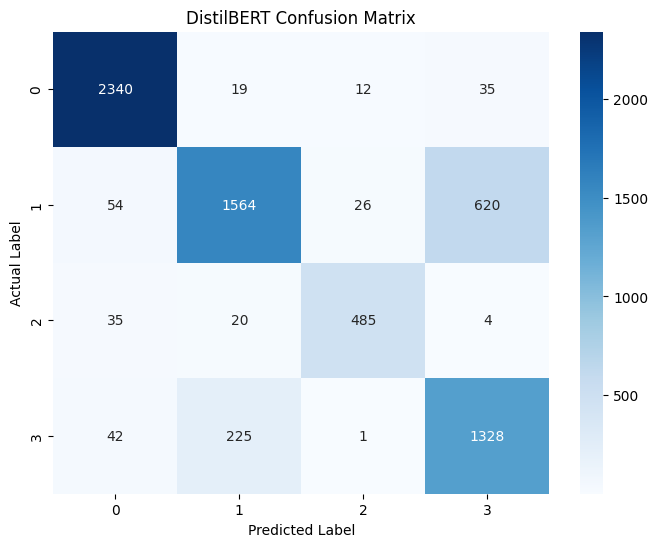

In [53]:

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("DistilBERT Confusion Matrix")

plt.show()

###  DistilBERT Confusion Matrix Analysis

#### Label Mapping

| Label | Class |
|---|---|
| 0 | Normal |
| 1 | Depression |
| 2 | Anxiety |
| 3 | Suicidal |

---

#### Understanding the Confusion Matrix

- Rows represent the **actual labels**
- Columns represent the **predicted labels**
- Diagonal values represent **correct predictions**
- Off-diagonal values represent **misclassifications**

A strong confusion matrix should ideally have:
- high diagonal values
- low off-diagonal values

---

#### Overall Observation

The confusion matrix shows strong diagonal dominance, indicating that the model performs well across most classes.

The largest confusion occurs between:
- **Depression**
- **Suicidal**

This is expected due to the strong semantic and emotional overlap between these categories in mental-health-related language.

---

#### Class-wise Analysis

##### 1. Normal Class

| Metric | Observation |
|---|---|
| Correct Predictions | 2340 / 2406 |

The model performs extremely well on the Normal class with very few misclassifications.

This indicates that neutral or non-mental-health-related language is lexically and semantically distinct from other classes.

---

##### 2. Depression Class

| Metric | Observation |
|---|---|
| Correct Predictions | 1564 / 2264 |
| Misclassified as Suicidal | 620 |

A significant number of Depression samples were classified as Suicidal.

This suggests strong overlap between:
- hopelessness
- despair
- emotional exhaustion
- suicidal ideation

Such confusion is psychologically meaningful and expected in real-world mental-health NLP systems.

---

##### 3. Anxiety Class

| Metric | Observation |
|---|---|
| Correct Predictions | 485 / 544 |

The Anxiety class achieved strong classification performance with very low confusion across other categories.

This indicates that DistilBERT successfully captured:
- contextual worry patterns
- anxious phrasing
- emotional tension

This represents a major improvement over classical TF-IDF-based models.

---

##### 4. Suicidal Class

| Metric | Observation |
|---|---|
| Correct Predictions | 1328 / 1596 |
| Misclassified as Depression | 225 |

The Suicidal class was classified well overall, although some overlap with Depression remained.

This is expected because suicidal language is often:
- implicit
- emotionally subtle
- context-dependent

---

#### Key Insights

#### Strong Diagonal Dominance
The model demonstrates strong overall classification capability with most predictions concentrated along the diagonal.

---

##### Depression ↔ Suicidal Overlap
The largest confusion occurred between Depression and Suicidal classes due to semantic similarity and overlapping emotional expressions.

---

##### Excellent Anxiety Detection
The transformer model showed strong contextual understanding for Anxiety-related language, significantly reducing confusion with other classes.

---

##### Minimal Anxiety ↔ Suicidal Confusion
Very few Anxiety samples were confused with Suicidal samples, indicating good semantic separation between these categories.

---

#### Conclusion

The confusion matrix confirms that DistilBERT provides:
- strong overall classification performance
- improved contextual understanding
- better minority-class detection
- meaningful semantic learning

The remaining errors primarily occur in semantically overlapping emotional categories, which reflects realistic challenges in mental-health NLP systems.